<a href="https://colab.research.google.com/github/rodrigocastillo69/KKD-Movie-Rating/blob/Prototipos_67_guys/Aplicaci%C3%B3n_del_proceso_KDD_Pelis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *1.¿Cual es el objetivo con este proyecto?*
### *Objetivo:* Clasificar si una pelicula va a ser un exito o fracaso en base a datos historicos como son:


*   Budget
*   Popularity
*   Runtime



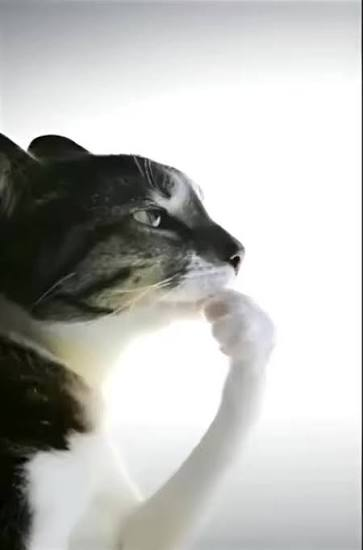

# *2.Seleccion de datos*


In [3]:
# Using the direct download link for Google Drive files
!gdown --remaining-ok "https://drive.google.com/uc?id=1JMFtsxftiYbfXy3ra01hk30FABKWXbI0" -O mi_dataset.csv

# Inspect the first few lines of the downloaded file to understand its structure
!head -n 5 mi_dataset.csv

import numpy as np
import pandas as pd

# 1.Cargar dataset desde el archivo CSV
df = pd.read_csv("mi_dataset.csv")

# 2.Filtrar solo registros con presupuesto y recaudación válidos
df_clean = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

# 3.Crear DataFrame con las características (X)
X = df_clean[["budget", "popularity", "runtime"]]

# 4.Crear variable objetivo (y): 1 si fue éxito, 0 si fue fracaso
y = (df_clean["revenue"] >= 2.5 * df_clean["budget"]).astype(int)
y.name = "exito"

# 5.Conocer el dataset
print("Dimensiones de X:", X.shape)

print("\nCaracterísticas:")
print(X.columns.tolist())

print("\nClases:")
print(np.unique(y))

Downloading...
From (original): https://drive.google.com/uc?id=1JMFtsxftiYbfXy3ra01hk30FABKWXbI0
From (redirected): https://drive.google.com/uc?id=1JMFtsxftiYbfXy3ra01hk30FABKWXbI0&confirm=t&uuid=584684c0-6f0d-478d-868e-320ef9354595
To: /content/mi_dataset.csv
100% 655M/655M [00:07<00:00, 83.7MB/s]
"id","title","vote_average","vote_count","status","release_date","revenue","runtime","adult","backdrop_path","budget","homepage","imdb_id","original_language","original_title","overview","popularity","poster_path","tagline","genres","production_companies","production_countries","spoken_languages","keywords"
"27205","Inception","8.364","34495","Released","2010-07-15","825532764","148","False","/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg","160000000","https://www.warnerbros.com/movies/inception","tt1375666","en","Inception","Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to b

In [4]:

# 1.Definir los nombres las clases (0 = Fracaso, 1 = Éxito)
target_names = np.array(["Fracaso", "Éxito"])

print("\nNombres de las clases:")
print(target_names)

# 2.DataFrame completo para visualización
df_vis = X.copy()

df_vis.insert(0, "titulo", df_clean["title"])

df_vis["exito"] = y.map({
    0: "Fracaso",
    1: "Éxito"
})

df_vis.head(10)


Nombres de las clases:
['Fracaso' 'Éxito']


,titulo,budget,popularity,runtime,exito
0,Inception,160000000,83.952,148,Éxito
1,Interstellar,165000000,140.241,169,Éxito
2,The Dark Knight,185000000,130.643,152,Éxito
3,Avatar,237000000,79.932,162,Éxito
4,The Avengers,220000000,98.082,143,Éxito
5,Deadpool,58000000,72.735,108,Éxito
6,Avengers: Infinity War,300000000,154.340,149,Éxito
7,Fight Club,63000000,69.498,139,Fracaso
8,Guardians of the Galaxy,170000000,33.255,121,Éxito
9,Pulp Fiction,8500000,74.862,154,Éxito


# *3.Limpieza*

In [5]:
# 1. Cargar el dataset original
df = pd.read_csv("mi_dataset.csv")

# 2. Filtrar películas estrenadas y con reporte financiero mínimo ($10,000 USD)
df_clean = df[
    (df["status"] == "Released")
    & (df["budget"] >= 10000)
    & (df["revenue"] >= 10000)
].copy()

# 3. Eliminar filas con datos faltantes (nulos) en columnas clave
df_clean = df_clean.dropna(
    subset=["genres", "release_date", "runtime", "title"]
)

# 4. Eliminar valores atípicos (outliers) en la duración (entre 45 y 300 minutos)
df_clean = df_clean[
    (df_clean["runtime"] >= 45) & (df_clean["runtime"] <= 300)
]

# 5. Descartar columnas de IDs, imágenes y texto libre que no usaremos
cols_a_descartar = [
    "id",
    "imdb_id",
    "overview",
    "tagline",
    "poster_path",
    "backdrop_path",
    "original_title",
    "status",
]
df_clean = df_clean.drop(
    columns=[c for c in cols_a_descartar if c in df_clean.columns]
)

# 6. Resetear el índice
df_clean = df_clean.reset_index(drop=True)

print(f"Filas originales: {len(df):,}")
print(f"Filas limpias para entrenamiento: {len(df_clean):,}")

Filas originales: 1,485,329
Filas limpias para entrenamiento: 9,772


In [16]:
from sklearn.model_selection import train_test_split

# 1. Definir matriz de características (X) y vector objetivo (y)
X = df_clean[["budget", "popularity", "runtime"]]  # Incluye aquí tus features finales
y = (df_clean["revenue"] >= 2.5 * df_clean["budget"]).astype(int)

# 2. VERIFICACIÓN DE DESBALANCE DE CLASES
print("Verificación de desbalance")
conteo = y.value_counts()
porcentajes = y.value_counts(normalize=True) * 100

resumen_clases = pd.DataFrame({
    "Etiqueta": ["Fracaso (0)", "Éxito (1)"],
    "Cantidad": conteo.values,
    "Porcentaje (%)": porcentajes.round(2).values
})
print(resumen_clases.to_string(index=False))

Verificación de desbalance
   Etiqueta  Cantidad  Porcentaje (%)
Fracaso (0)      5881           60.18
  Éxito (1)      3891           39.82


In [15]:
# 1. DIVISIÓN DEL DATASET (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% para el conjunto de prueba
    random_state=42,     # Semilla fija para reproducibilidad
    stratify=y           # Mantiene la proporción de clases original
)

print("\n DIVISIÓN COMPLETADA ")
print(f"Conjunto total: {len(X):,} filas")
print(f"Entrenamiento (X_train): {X_train.shape[0]:,} filas ({len(X_train)/len(X)*100:.0f}%)")
print(f"Prueba (X_test): {X_test.shape[0]:,} filas ({len(X_test)/len(X)*100:.0f}%)")


 DIVISIÓN COMPLETADA 
Conjunto total: 9,772 filas
Entrenamiento (X_train): 7,817 filas (80%)
Prueba (X_test): 1,955 filas (20%)


# *4.Normalización*

In [17]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Definir las columnas numéricas continuas a escalar
cols_numericas = ["budget", "popularity", "runtime"]

# Crear copias para conservar la estructura
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 3. FIT + TRANSFORM solo en Train / TRANSFORM en Test
X_train_scaled[cols_numericas] = scaler.fit_transform(
    X_train[cols_numericas]
)
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

# Inspección de los datos transformados (ahora tienen media ~0 y std ~1)
print("VISTA PREVIA DE X_train ESCALADO")
print(X_train_scaled[cols_numericas].head())

VISTA PREVIA DE X_train ESCALADO
        budget  popularity   runtime
7417 -0.504307   -0.136195 -0.460199
3402 -0.516830   25.680352 -0.636844
2402  1.624545    0.057736 -0.416038
5047 -0.003401   -0.081944 -0.416038
7464 -0.582349   -0.218554 -0.460199


# *5.Minería de datos*

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Crear el modelo con 100 árboles de decisión
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train_scaled, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred = rf_model.predict(X_test_scaled)

# 4. Evaluación del rendimiento
print("Matriz de confusión")
print(confusion_matrix(y_test, y_pred))

print("\n Clasificacíon" )
print(classification_report(y_test, y_pred, target_names=["Fracaso", "Éxito"]))

=== MATRIZ DE CONFUSIÓN ===
[[922 255]
 [372 406]]

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Fracaso       0.71      0.78      0.75      1177
       Éxito       0.61      0.52      0.56       778

    accuracy                           0.68      1955
   macro avg       0.66      0.65      0.66      1955
weighted avg       0.67      0.68      0.67      1955



# *6.Evaluación*

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcular métricas individuales para la evaluación del modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Imprimir resultados
print(" Evaluacion del modelo ")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

 Evaluacion del modelo 
Accuracy:  0.6793
Precision: 0.6142
Recall:    0.5219
F1-Score:  0.5643


In [11]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 67.93%


# *7.Interpretación*

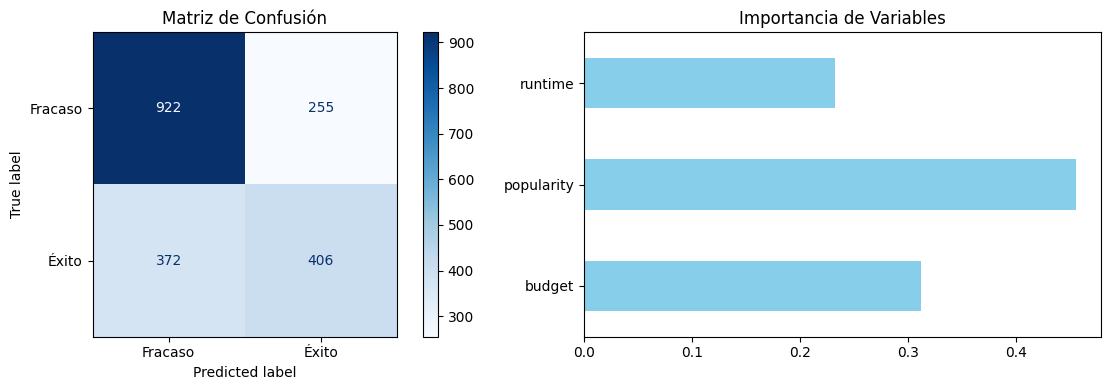

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

# Lienzo para las 2 gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Fracaso", "Éxito"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Matriz de Confusión")

# 2. Importancia de Variables
pd.Series(rf_model.feature_importances_, index=X_train.columns).plot(
    kind="barh", ax=axes[1], color="skyblue"
)
axes[1].set_title("Importancia de Variables")

plt.tight_layout()
plt.show()

El modelo es bueno para clasificar que una pelicula va a ser fracaso ya que su recall es de 78% financieramente, la cuestion es que cuando clasifica Exitos le cuesta trabajo y se nota en su acuraccy que es del 67.93% casi la mitad de los resultados no los puede clasificar, esto puede mejorar si se metieran mas variables tipo "Genero de la pelicula" o optar por usar un modelo mas avanzado.